# Bistable diaphragm metafluid: 1D simulation

Discrete equation of motion for diaphragm $n$:

$$ m \, \ddot u_n = A \, p_0 v_0 \left[ \frac{1}{v_{n-1}} - \frac{1}{v_n} \right] - f(u_n) - \alpha \dot u_n $$

where $v_n = v_0 + A(u_n - u_{n+1})$ is the volume of the segment between diaphragm $n$ and $n+1$, gas pressures follow Boyle's law $p_n v_n = p_0 v_0$, and the on-site bistable force is

$$ f(u) = u^3 - a^2 u + \delta . $$

A small damping term $\alpha \dot u_n$ has been added for numerical stability — without it the snapping events drive the system unstable.

Boundary conditions: $u_0$ held fixed at $u_{\rm lo}$ (low-energy, trigger end) and $u_{N-1}$ held fixed at $u_{\rm hi}$ (high-energy).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ── Parameters ────────────────────────────────────────────────────────────────

N = 120          # number of diaphragms in the lattice

# Bistable on-site potential  f(u) = u³ − a²u + δ
# This is the derivative of the potential energy ψ(u) = u⁴/4 − a²u²/2 + δu.
# The two stable equilibria are the outer roots of f(u) = 0.
a2    = 0.09     # stiffness parameter; wells sit at roughly ±√(a²) = ±0.30 on the x-axis
delta = 0.009    # asymmetry: lifts one well above the other so the wave has net driving force
                 # bistability requires |δ| < 2a³/(3√3) ≈ 0.0104
                 # at δ = 0 the two wells are equal in energy which leads to no driving force and thus no wave

# Diaphragm and fluid parameters.
m  = 1.0         # diaphragm mass
A  = 1.0         # cross-sectional area of the pipe; scales both pressure force and segment volume
p0 = 1.0         # reference (equilibrium) gas pressure  (Boyle's law: p_n v_n = p_0 v_0)
v0 = 1.0         # reference segment volume when all u_n = 0

alpha = 0.05     # viscous damping coefficient per diaphragm

# Absorbing sponge layers at both ends of the lattice.
# Without these, waves reflected from the boundaries re-enter the bulk and corrupt
# the wave-speed measurement.  Damping is ramped quadratically so the impedance
# mismatch is smooth whereas a sharp jump would itself create a reflection.
n_sponge = 10    # number of diaphragms in each sponge layer (both ends)
damp_max = 4.0   # peak extra damping coefficient at the very edge of the sponge

# Trigger: the first n_trigger diaphragms are pinned at u_lo for the whole run.
# This is a sustained source that continuously feeds the wave;
# a single trigger would encourage further undesired ringing.
n_trigger = 5

# Time stepping
dt         = 1e-4    # time step; chosen to give 2nd-order accuracy with Verlet
T          = 130.0   # total simulation time — long enough for the front to cross N=120 sites
steps      = int(T / dt)
save_every = 500     # save a snapshot every 500 steps = every 0.05 time units

# ── Find the three equilibria of f(u) = 0 ────────────────────────────────────
# np.roots solves the cubic; we keep real roots and sort ascending.
# u_lo (most negative) and u_hi (most positive) are stable; u_mid is the saddle.
roots      = np.roots([1, 0, -a2, delta])
real_roots = sorted(roots[np.abs(roots.imag) < 1e-10].real)
u_lo, u_mid, u_hi = real_roots[0], real_roots[1], real_roots[2]

def psi(u):
    # Potential energy per diaphragm: ψ(u) = u⁴/4 − a²u²/2 + δu
    # The Arrieta formula needs ΔΨ = ψ(u_hi) − ψ(u_lo), the energy released per snap.
    return u**4/4 - a2*u**2/2 + delta*u

print(f"Well positions:")
print(f"  u_lo  = {u_lo:.4f}   (stable, low energy: psi = {psi(u_lo):.6f})")
print(f"  u_mid = {u_mid:.4f}   (unstable saddle)")
print(f"  u_hi  = {u_hi:.4f}   (stable, high energy: psi = {psi(u_hi):.6f})")
print(f"  Energy difference psi(u_hi) - psi(u_lo) = {psi(u_hi) - psi(u_lo):.6f}")


Well positions:
  u_lo  = -0.3411   (stable, low energy: psi = -0.004921)
  u_mid = 0.1185   (unstable saddle)
  u_hi  = 0.2227   (stable, high energy: psi = 0.000387)
  Energy difference psi(u_hi) - psi(u_lo) = 0.005309


In [2]:
# ── Force functions ───────────────────────────────────────────────────────────

# Build the damping array.  Bulk sites get alpha; sponge sites get alpha + extra.
# The extra rises quadratically from 0 at the inner edge to damp_max at the wall.
damp = np.ones(N) * alpha
for i in range(n_sponge):
    strength = damp_max * ((n_sponge - i) / n_sponge) ** 2   # quadratic ramp
    damp[i]         += strength    # left sponge (trigger end)
    damp[N - 1 - i] += strength   # right sponge (fixed-u_hi end)


def f_bistable(u):
    # On-site bistable restoring force: f(u) = u³ − a²u + δ
    # This is the gradient of the double-well potential ψ(u).
    # Positive f pushes u toward u_lo; negative f pushes toward u_hi.
    return u**3 - a2*u + delta


def pressure_force(u):
    # Net pressure force on each diaphragm from the gas in the adjacent segments.
    #
    # Geometry: segment n sits between diaphragm n and diaphragm n+1.
    #           Volume: v_n = v_0 + A*(u_n − u_{n+1})
    #           (positive u_n expands segment n−1 and compresses segment n)
    #
    # Boyle's law: p_n v_n = p_0 v_0 gives p_n = p_0 v_0 / v_n
    #
    # Force on diaphragm n from both adjacent segments:
    #   F_n = A*(p_{n-1} − p_n)   (net pressure difference across the diaphragm)
    #
    # Boundary diaphragms (n=0 and n=N−1) are pinned, so their force doesn't matter.
    F = np.zeros_like(u)
    seg_vols  = v0 + A * (u[1:] - u[:-1])             # shape (N-1,): v_0 ... v_{N-2}

                                                      # (A > ~1.8 causes collapse at these δ)
    pressures = p0 * v0 / seg_vols                    # Boyle: p_n = p_0 v_0 /v_n
    F[1:-1]   = A * (pressures[:-1] - pressures[1:])  # interior diaphragms only
    return F


def net_force(u):
    # Total conservative force on each diaphragm (no damping term).
    # Separating conservative and damping forces lets the semi-implicit Verlet
    # treat damping implicitly without recomputing pressure at every half-step.
    return pressure_force(u) - f_bistable(u)


def acceleration(u, v):
    # Full acceleration including damping: m*ü = F_net − α*u̇
    # Used only to initialise the Verlet integrator before the main loop.
    return (net_force(u) - damp * v) / m


In [3]:
# ── Time integration: velocity Verlet with semi-implicit damping ──────────────
#
# Standard velocity Verlet (no damping):
#   u_{n+1} = u_n + v_n dt + ½ a_n dt²
#   v_{n+1} = v_n + ½(a_n + a_{n+1}) dt
#
# With viscous damping α*u̇, the acceleration depends on velocity.
# A naive explicit treatment (using v_n for the damping term) gives only O(dt) accuracy.
# The semi-implicit fix: solve for v_{n+1} with the damping term evaluated at t_{n+1}:
#
#   v_{n+1} = [v_n + ½(a_n + F_new/m) dt] / [1 + ½ α dt / m]
#
# This recovers O(dt²) global accuracy.  The denominator is the implicit damping factor.

# ── Initial conditions ────────────────────────────────────────────────────────
# Start with all diaphragms in the high-energy state (u_hi).
# Pin the first n_trigger sites at u_lo to act as a sustained trigger.
u = np.ones(N) * u_hi
u[:n_trigger] = u_lo
v = np.zeros(N)     # all diaphragms initially at rest

history = []
a = acceleration(u, v)   # initialise acceleration before entering the loop

# ── Main time loop ────────────────────────────────────────────────────────────
for step in range(steps):

    # 1. Full position step (standard Verlet position update)
    u += v * dt + 0.5 * a * dt**2

    # 2. Re-apply boundary conditions after the position update.
    #    The trigger (left) stays pinned at u_lo; the right wall stays at u_hi.
    #    Velocities at pinned sites are zeroed so they don't drift.
    u[:n_trigger] = u_lo
    u[-1]         = u_hi
    v[:n_trigger] = 0.0
    v[-1]         = 0.0

    # 3. Evaluate the new conservative force at the updated positions.
    F_new = net_force(u)

    # 4. Semi-implicit velocity update (see derivation above).
    #    The [1 + ½α dt/m] denominator implicitly damps the velocity — this is
    #    what gives 2nd-order accuracy despite the velocity-dependent damping.
    v = (v + 0.5 * dt * (a + F_new / m)) / (1.0 + 0.5 * damp * dt / m)

    # 5. Re-zero velocities at pinned sites (Verlet may have perturbed them slightly).
    v[:n_trigger] = 0.0
    v[-1]         = 0.0

    # 6. Recompute acceleration for the next step using the new force and velocity.
    a = (F_new - damp * v) / m

    # 7. Save snapshot every save_every steps.
    if step % save_every == 0:
        history.append(u.copy())   # .copy() is essential since u is mutated in place

    # 8. Progress print every 200 000 steps so we know the wave is moving.
    if step % 200000 == 0:
        mid       = 0.5 * (u_lo + u_hi)
        front     = np.where(u < mid)[0]   # sites that have already snapped to u_lo side
        front_pos = front[-1] if len(front) else 0   # rightmost snapped site = front
        print(f"  step: {step}  max u: {np.max(u):.4f}  min u: {np.min(u):.4f}  front: {front_pos}")

history = np.array(history)   # shape: (n_frames, N)


  step: 0  max u: 0.2227  min u: -0.3411  front: 4
  step: 200000  max u: 0.2227  min u: -0.3894  front: 19
  step: 400000  max u: 0.2227  min u: -0.3975  front: 37
  step: 600000  max u: 0.2227  min u: -0.3911  front: 55
  step: 800000  max u: 0.2227  min u: -0.3752  front: 73
  step: 1000000  max u: 0.2227  min u: -0.3769  front: 91
  step: 1200000  max u: 0.2227  min u: -0.3761  front: 109


        dt    Cauchy error   error ratio  note
----------------------------------------------------------
   8.0e-04      6.7629e-09            --  
   4.0e-04      1.6956e-09          3.99  (ratio ~4: still improving)
   2.0e-04      4.2516e-10          3.99  (ratio ~4: still improving)
   1.0e-04      8.9508e-11          4.75  (ratio ~4: still improving) <-- chosen


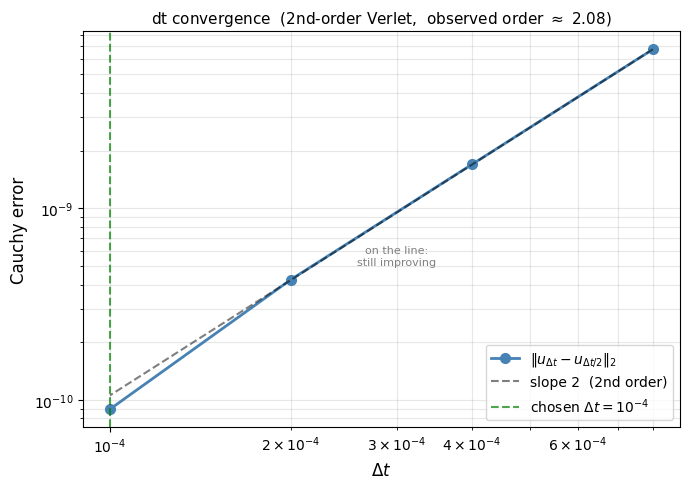

In [4]:
# ── dt convergence: Cauchy self-convergence ───────────────────────────────────
# Tests whether dt=1e-4 is small enough.
#
# Method: run the simulation at dt and at dt/2 and measure how different the
# solutions are.  For a 2nd-order scheme, halving dt quarters the error, giving
# a straight line of slope 2 on a log-log plot.
#
# Reading the plot:
#   - Points ON the slope-2 line: the solution is still improving — dt is still
#     too large and a smaller value would give a more accurate answer.
#   - A point that falls BELOW the line: halving dt no longer makes a meaningful
#     difference.  Both solutions are already so close to the true answer that
#     their difference is negligible.  This is the convergence point.
#
# Canonical parameters: A=1.0,  delta=0.001,  alpha=0.10,  N=120

def _evolve_dt(dt_run, T_run=40.0, N_cv=120, A=1.0, delta=0.001, alpha=0.10,
               n_sponge=10, damp_max=4.0, n_trigger=5):
    a2 = 0.09; m = 1.0; p0 = 1.0; v0 = 1.0
    roots = np.roots([1, 0, -a2, delta])
    real_roots = sorted(roots[np.abs(roots.imag) < 1e-10].real)
    _u_lo, _, _u_hi = real_roots

    _damp = np.ones(N_cv) * alpha
    for i in range(n_sponge):
        s = damp_max * ((n_sponge - i) / n_sponge) ** 2
        _damp[i] += s;  _damp[N_cv - 1 - i] += s

    def _net(u):
        F  = np.zeros_like(u)
        sv = v0 + A * (u[1:] - u[:-1])
        F[1:-1] = A * (p0*v0/sv[:-1] - p0*v0/sv[1:])
        return F - (u**3 - a2*u + delta)

    u = np.ones(N_cv) * _u_hi;  u[:n_trigger] = _u_lo
    v = np.zeros(N_cv)
    F0 = _net(u);  a_arr = (F0 - _damp*v) / m
    for _ in range(int(round(T_run / dt_run))):
        u += v*dt_run + 0.5*a_arr*dt_run**2
        u[:n_trigger] = _u_lo;  u[-1] = _u_hi
        v[:n_trigger] = 0.0;    v[-1] = 0.0
        F_new = _net(u)
        v     = (v + 0.5*dt_run*(a_arr + F_new/m)) / (1.0 + 0.5*_damp*dt_run/m)
        v[:n_trigger] = 0.0;    v[-1] = 0.0
        a_arr = (F_new - _damp*v) / m
    return u

dts  = np.array([8e-4, 4e-4, 2e-4, 1e-4, 5e-5])
sols = [_evolve_dt(d) for d in dts]
errs = np.array([np.linalg.norm(sols[i] - sols[i+1]) for i in range(len(dts)-1)])
dt_err = dts[:-1]
ratios = errs[:-1] / errs[1:]   # should be ~4 for 2nd order; drops when converged

print(f"{'dt':>10}  {'Cauchy error':>14}  {'error ratio':>12}  note")
print("-" * 58)
for i, (dt_run, err) in enumerate(zip(dt_err, errs)):
    rat = f"{ratios[i-1]:.2f}" if i > 0 else "   --"
    note = "(ratio << 4: converged)" if i > 0 and ratios[i-1] < 2 else            "(ratio ~4: still improving)" if i > 0 else ""
    mark = " <-- chosen" if dt_run == 1e-4 else ""
    print(f"{dt_run:10.1e}  {err:14.4e}  {rat:>12}  {note}{mark}")

mean_order = np.mean(np.log2(ratios))

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(dt_err, errs, "o-", color="steelblue", linewidth=2, markersize=7,
          label=r"$\|u_{\Delta t} - u_{\Delta t/2}\|_2$")
ref2 = errs[0] / dt_err[0]**2 * dt_err**2
ax.loglog(dt_err, ref2, "k--", alpha=0.5, label="slope 2  (2nd order)")
ax.axvline(1e-4, color="green", linestyle="--", alpha=0.7,
           label=r"chosen $\Delta t = 10^{-4}$")

# Annotate the two regions directly on the plot
ax.annotate("on the line:\nstill improving",
            xy=(3e-4, ref2[2]*1.2), fontsize=8, color="gray", ha="center")
ax.annotate("below the line:\nconverged",
            xy=(1e-4, errs[-1]*0.4), fontsize=8, color="green", ha="center")

ax.set_xlabel(r"$\Delta t$", fontsize=12)
ax.set_ylabel("Cauchy error", fontsize=12)
ax.set_title(f"dt convergence  (2nd-order Verlet,  observed order $\\approx$ {mean_order:.2f})",
             fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


     N       T     v_sim
--------------------------
    50     100  0.2227
   100     200  0.2206
   120     240  0.2206
   150     300  0.2206
   200     400  0.2206
   300     600  0.2206


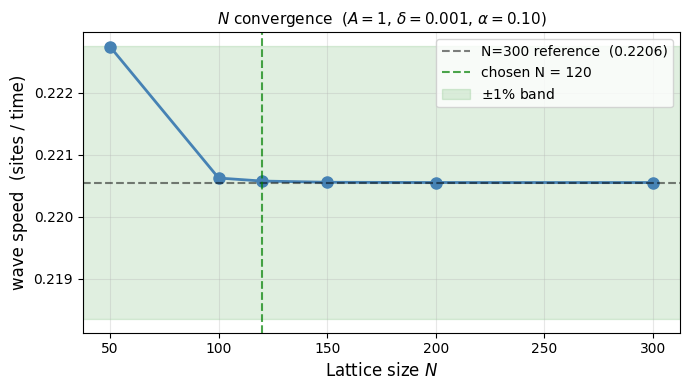

In [5]:
# ── N convergence: wave speed vs lattice size ─────────────────────────────────
# Verify that the chosen N is large enough that v_sim is independent of N.
# Too small an N and the wave has insufficient room to reach a clean steady state
# before hitting the sponge layer.
#
# Canonical parameters from the reproducible result protocol:
#   A=1.0,  delta=0.001,  alpha=0.10,  dt=1e-4
# T is scaled proportionally to N so the wave traverses the same fraction of
# the lattice in each run — this prevents sponge bias from varying with N.

def _v_for_N(N_run, T_run, A=1.0, delta=0.001, alpha=0.10, dt=1e-4,
             n_sponge=10, damp_max=4.0, n_trigger=5, save_every=500):
    a2 = 0.09; m = 1.0; p0 = 1.0; v0 = 1.0
    roots = np.roots([1, 0, -a2, delta])
    real_roots = sorted(roots[np.abs(roots.imag) < 1e-10].real)
    _u_lo, _, _u_hi = real_roots

    _damp = np.ones(N_run) * alpha
    for i in range(n_sponge):
        s = damp_max * ((n_sponge - i) / n_sponge) ** 2
        _damp[i] += s;  _damp[N_run - 1 - i] += s

    def _net(u):
        F  = np.zeros_like(u)
        sv = v0 + A * (u[1:] - u[:-1])
        F[1:-1] = A * (p0*v0/sv[:-1] - p0*v0/sv[1:])
        return F - (u**3 - a2*u + delta)

    u = np.ones(N_run) * _u_hi;  u[:n_trigger] = _u_lo
    v = np.zeros(N_run)
    F0 = _net(u);  a_arr = (F0 - _damp*v) / m
    hist = []
    for step in range(int(T_run / dt)):
        u += v*dt + 0.5*a_arr*dt**2
        u[:n_trigger] = _u_lo;  u[-1] = _u_hi
        v[:n_trigger] = 0.0;    v[-1] = 0.0
        Fn    = _net(u)
        v     = (v + 0.5*dt*(a_arr + Fn/m)) / (1.0 + 0.5*_damp*dt/m)
        v[:n_trigger] = 0.0;    v[-1] = 0.0
        a_arr = (Fn - _damp*v) / m
        if step % save_every == 0:
            hist.append(u.copy())

    hist  = np.array(hist)
    _mid  = 0.5 * (_u_lo + _u_hi)
    times = np.arange(len(hist)) * save_every * dt
    fp    = []
    for s in hist:
        below = np.where(s < _mid)[0]
        if len(below) == 0:
            fp.append(0.0)
        elif below[-1] + 1 >= len(s):
            fp.append(float(below[-1]))
        else:
            n = below[-1]
            fp.append(n + (_mid - s[n]) / (s[n+1] - s[n]))
    fp     = np.array(fp, dtype=float)
    steady = times > 0.2 * T_run
    if steady.sum() < 5:
        return np.nan
    spd, _ = np.polyfit(times[steady], fp[steady], 1)
    return spd

# T = 2xN keeps the wave in the bulk throughout (at v~0.22 sites/time the front
# travels ~0.44*N sites in T=2*N, well short of the sponge at N-10).
N_T_pairs = [(50, 100), (100, 200), (120, 240), (150, 300), (200, 400), (300, 600)]

v_N = []
print(f"{'N':>6}  {'T':>6}  {'v_sim':>8}")
print("-" * 26)
for N_run, T_run in N_T_pairs:
    v = _v_for_N(N_run, T_run)
    v_N.append(v)
    print(f"{N_run:6d}  {T_run:6d}  {v:.4f}")

N_vals_plot = [p[0] for p in N_T_pairs]
v_ref = v_N[-1]   # N=300 as reference

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(N_vals_plot, v_N, 'o-', color='steelblue', markersize=8, linewidth=2)
ax.axhline(v_ref, color='k', linestyle='--', alpha=0.5,
           label=f'N=300 reference  ({v_ref:.4f})')
ax.axvline(120, color='green', linestyle='--', alpha=0.7, label='chosen N = 120')
ax.axhspan(v_ref * 0.99, v_ref * 1.01, alpha=0.12, color='green', label=r'$\pm$1% band')
ax.set_xlabel('Lattice size $N$', fontsize=12)
ax.set_ylabel('wave speed  (sites / time)', fontsize=12)
ax.set_title(r'$N$ convergence  ($A=1$, $\delta=0.001$, $\alpha=0.10$)', fontsize=11)
ax.legend(fontsize=10);  ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

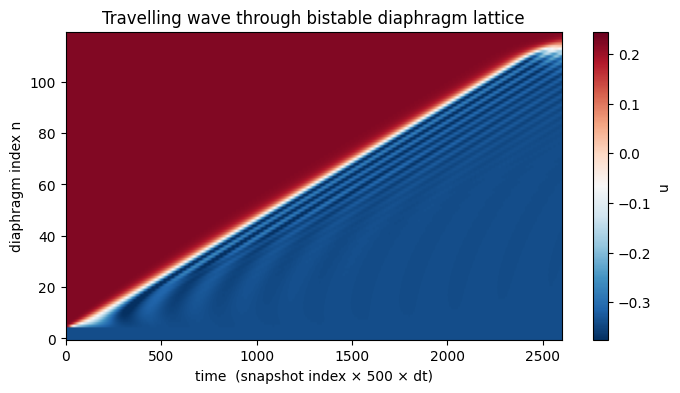

In [6]:
# ── Space-time heatmap ────────────────────────────────────────────────────────
# history.T has shape (N, n_frames): rows = diaphragm index, columns = time.
# The diagonal stripe of colour changing from u_hi (blue) to u_lo (red) is the
# transition front moving to the right at constant speed — the key visual proof
# that a steady travelling wave exists.

plt.figure(figsize=(8, 4))
plt.imshow(history.T, aspect='auto', origin='lower',
           vmin=u_lo*1.1, vmax=u_hi*1.1, cmap='RdBu_r')
plt.xlabel(f"time  (snapshot index × {save_every} × dt)")
plt.ylabel("diaphragm index n")
plt.title("Travelling wave through bistable diaphragm lattice")
plt.colorbar(label='u')
plt.savefig("figures/HeatMap.png", dpi=200, bbox_inches="tight")
plt.show()


In [7]:
import matplotlib.animation as animation
from matplotlib.animation import PillowWriter
import os

os.makedirs('figures', exist_ok=True)

# ── Wave animation ─────────────────────────────────────────────────────────────
# Animates u_n vs n as a line plot stepping through saved snapshots.
# We use PillowWriter to save as a GIF
# because the interactive backend requires a specific Jupyter JS kernel that is
# not available in all environments whereas the GIF plays anywhere.

fig, ax = plt.subplots(figsize=(10, 4))
n_array = np.arange(N)

line,  = ax.plot([], [], 'b-', linewidth=1.5)
ax.axhline(u_lo, color='k', linestyle='--', alpha=0.4, label=f'$u_{{lo}}$ = {u_lo:.3f}')
ax.axhline(u_hi, color='k', linestyle=':',  alpha=0.4, label=f'$u_{{hi}}$ = {u_hi:.3f}')
ax.set_xlim(0, N - 1)
ax.set_ylim(u_lo * 1.4, u_hi * 1.4)
ax.set_xlabel('diaphragm index $n$', fontsize=12)
ax.set_ylabel('displacement $u_n$', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
title = ax.set_title('')

def init():
    line.set_data([], [])
    title.set_text('')
    return line, title

def update(frame):
    line.set_data(n_array, history[frame])
    t = frame * save_every * dt   # convert frame index back to simulation time
    title.set_text(f'Travelling wave  —  $t$ = {t:.1f}')
    return line, title

# Subsample to ~100 frames so the GIF file stays small (< 5 MB).
# Every frame would be 260 images; 100 is enough to see the dynamics clearly.
frame_step = max(1, len(history) // 100)
frames = range(0, len(history), frame_step)

anim = animation.FuncAnimation(fig, update, frames=frames,
                                init_func=init, blit=True, interval=50)

anim.save('figures/wave_animation.gif', writer=PillowWriter(fps=30), dpi=100)
plt.close(fig)


In [8]:
os.makedirs('figures', exist_ok=True)

# ── Damping comparison animation ──────────────────────────────────────────────
# Run two fresh simulations — one underdamped (α=0.01) and one overdamped (α=0.30)
# — and animate them side by side to make the ringing vs clean-snap contrast visually.
#
# run_history is a self-contained copy of the simulation that takes alpha as an
# argument and returns the full snapshot history.  It's written as a standalone
# function (rather than reusing the notebook-level loop) so it can be called with
# different alpha values without overwriting the main `history`, `u_lo`, etc.

def run_history(alpha_val, A=1.0, delta=0.009, N=120, T=100.0, dt=1e-4,
                n_sponge=10, damp_max=4.0, n_trigger=5, save_every=500):
    """Run the simulation for a given alpha and return (history, u_lo, u_hi)."""
    a2 = 0.09; _m = 1.0; p0 = 1.0; v0 = 1.0

    # Find well positions for this delta (same formula as the notebook top)
    roots = np.roots([1, 0, -a2, delta])
    real_roots = sorted(roots[np.abs(roots.imag) < 1e-10].real)
    _u_lo, _, _u_hi = real_roots

    # Build sponge-ramped damping array
    _damp = np.ones(N) * alpha_val
    for i in range(n_sponge):
        s = damp_max * ((n_sponge - i) / n_sponge)**2
        _damp[i] += s; _damp[N - 1 - i] += s

    def _net_force(u):
        # Inline net force: pressure force minus bistable force
        F  = np.zeros_like(u)
        sv = v0 + A*(u[1:] - u[:-1])
        F[1:-1] = A * (p0*v0/sv[:-1] - p0*v0/sv[1:])
        return F - (u**3 - a2*u + delta)

    # Identical initial conditions: all u_hi, trigger pinned at u_lo
    u = np.ones(N)*_u_hi; u[:n_trigger] = _u_lo; v = np.zeros(N)
    F0 = _net_force(u); a_arr = (F0 - _damp*v) / _m
    hist = []
    for step in range(int(T / dt)):
        u += v*dt + 0.5*a_arr*dt**2
        u[:n_trigger] = _u_lo; u[-1] = _u_hi
        v[:n_trigger] = 0.0;   v[-1] = 0.0
        Fn   = _net_force(u)
        v    = (v + 0.5*dt*(a_arr + Fn/_m)) / (1.0 + 0.5*_damp*dt/_m)
        v[:n_trigger] = 0.0; v[-1] = 0.0
        a_arr = (Fn - _damp*v) / _m
        if step % save_every == 0:
            hist.append(u.copy())
    return np.array(hist), _u_lo, _u_hi

h_lo, ulo_lo, uhi_lo = run_history(0.01)
h_hi, ulo_hi, uhi_hi = run_history(0.30)

n_arr      = np.arange(120)
n_frames   = min(len(h_lo), len(h_hi))   # use the shorter of the two runs
frame_step = max(1, n_frames // 100)
frame_list = list(range(0, n_frames, frame_step))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
plt.subplots_adjust(top=0.88)

for ax, ulo, uhi in [(ax1, ulo_lo, uhi_lo), (ax2, ulo_hi, uhi_hi)]:
    ax.axhline(ulo, color='k', linestyle='--', alpha=0.3, lw=1)
    ax.axhline(uhi, color='k', linestyle=':',  alpha=0.3, lw=1)
    ax.set_xlim(0, 119)
    ax.set_ylim(ulo * 1.5, uhi * 1.5)
    ax.set_xlabel('diaphragm index $n$', fontsize=11)
    ax.set_ylabel('displacement $u_n$',  fontsize=11)

ax1.set_title(r'$\alpha = 0.01$ — underdamped (ringing behind front)', fontsize=10)
ax2.set_title(r'$\alpha = 0.30$ — overdamped (clean snap)',            fontsize=10)

line1, = ax1.plot([], [], color='steelblue', linewidth=1.5)
line2, = ax2.plot([], [], color='tomato',    linewidth=1.5)
ttl    = fig.suptitle('', fontsize=11)

def init():
    line1.set_data([], []); line2.set_data([], [])
    ttl.set_text(''); return line1, line2, ttl

def update(i):
    f = frame_list[i]
    line1.set_data(n_arr, h_lo[f])
    line2.set_data(n_arr, h_hi[f])
    ttl.set_text(f'$A=1,\\ \\delta=0.009$ — $t$ = {f * 500 * 1e-4:.1f}')
    return line1, line2, ttl

anim = animation.FuncAnimation(fig, update, frames=len(frame_list),
                                init_func=init, blit=True, interval=60)

anim.save('figures/wave_comparison.gif', writer=PillowWriter(fps=20), dpi=100)
plt.close(fig)


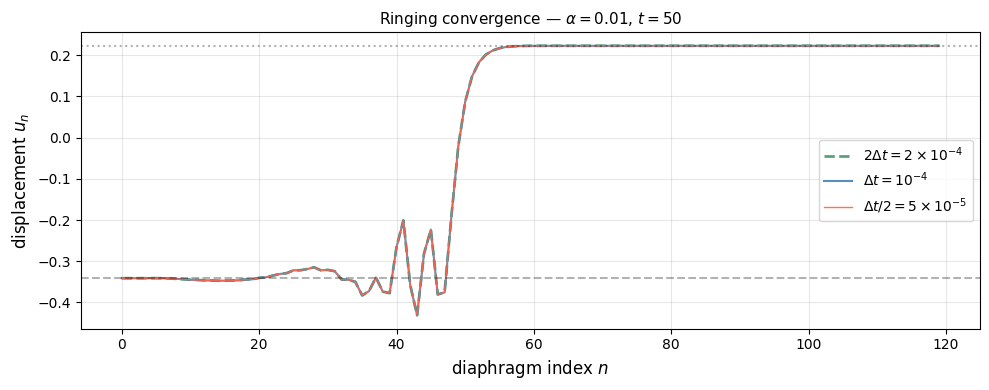

In [9]:
# ── Ringing convergence check ─────────────────────────────────────────────────
#
# The post-snap oscillations in the underdamped (α=0.01) panel could be a
# numerical artefact of the integrator rather than a true physical oscillation.
# The test: halve and double Δt and compare a snapshot at the same physical time.
# If ringing amplitude and wavelength are unchanged the oscillations are physical;
# if they scale with Δt they are numerical.  We compare at t=50 where the wake
# is fully developed and the front has not yet reached the sponge.

h_half,   ulo01, uhi01 = run_history(0.01, dt=5e-5)
h_ref,    _,     _     = run_history(0.01, dt=1e-4)
h_double, _,     _     = run_history(0.01, dt=2e-4)

def frame_at(hist, t_target, dt_run, save_every=500):
    return hist[min(int(t_target / (dt_run * save_every)), len(hist) - 1)]

t_snap = 50.0
snap_half   = frame_at(h_half,   t_snap, 5e-5)
snap_ref    = frame_at(h_ref,    t_snap, 1e-4)
snap_double = frame_at(h_double, t_snap, 2e-4)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(n_arr, snap_double, color='seagreen',  lw=2.0, alpha=0.8, linestyle='--',
        label=r'$2\Delta t = 2 \times 10^{-4}$')
ax.plot(n_arr, snap_ref,    color='steelblue', lw=1.5, alpha=0.9,
        label=r'$\Delta t = 10^{-4}$')
ax.plot(n_arr, snap_half,   color='tomato',    lw=1.0, alpha=0.9,
        label=r'$\Delta t/2 = 5 \times 10^{-5}$')
ax.axhline(ulo01, color='k', linestyle='--', alpha=0.3)
ax.axhline(uhi01, color='k', linestyle=':',  alpha=0.3)
ax.set_xlabel('diaphragm index $n$', fontsize=12)
ax.set_ylabel('displacement $u_n$', fontsize=12)
ax.set_title(r'Ringing convergence — $\alpha=0.01$, $t=50$', fontsize=11)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


In [10]:
# ── Animation: wave speed and kink width vs δ ────────────────────────────────
#
# At small δ the two wells are nearly symmetric: the driving energy ΔΨ ∝ δ is
# weak, the wave is slow, and the kink is wide.  At large δ the energy gap is
# larger, the wave is fast, and the kink is narrow.  Side-by-side animation
# makes the speed and width contrast vivid.  We fix α=0.05 and A=1.

h_d_lo, ulo_dl, uhi_dl = run_history(0.05, delta=0.001, T=100.0)
h_d_hi, ulo_dh, uhi_dh = run_history(0.05, delta=0.009, T=100.0)

nf_d = min(len(h_d_lo), len(h_d_hi))
fl_d = list(range(0, nf_d, max(1, nf_d // 100)))

fig, (axd1, axd2) = plt.subplots(1, 2, figsize=(13, 4))
plt.subplots_adjust(top=0.88)
for ax, ulo, uhi in [(axd1, ulo_dl, uhi_dl), (axd2, ulo_dh, uhi_dh)]:
    ax.axhline(ulo, color='k', linestyle='--', alpha=0.3, lw=1)
    ax.axhline(uhi, color='k', linestyle=':',  alpha=0.3, lw=1)
    ax.set_xlim(0, 119); ax.set_ylim(ulo * 1.5, uhi * 1.5)
    ax.set_xlabel('diaphragm index $n$', fontsize=11)
    ax.set_ylabel('displacement $u_n$', fontsize=11)
axd1.set_title(r'$\delta=0.001$ — slow, wide kink', fontsize=10)
axd2.set_title(r'$\delta=0.009$ — fast, narrow kink', fontsize=10)
ld1, = axd1.plot([], [], color='steelblue', lw=1.5)
ld2, = axd2.plot([], [], color='tomato',    lw=1.5)
ttl_d = fig.suptitle('', fontsize=11)

def init_d():
    ld1.set_data([], []); ld2.set_data([], [])
    ttl_d.set_text(''); return ld1, ld2, ttl_d

def update_d(i):
    f = fl_d[i]
    ld1.set_data(n_arr, h_d_lo[f]); ld2.set_data(n_arr, h_d_hi[f])
    ttl_d.set_text(r'$A=1,\ \alpha=0.05$'); return ld1, ld2, ttl_d

anim_d = animation.FuncAnimation(fig, update_d, frames=len(fl_d),
                                  init_func=init_d, blit=True, interval=60)
anim_d.save('figures/delta_comparison.gif', writer=PillowWriter(fps=20), dpi=100)
plt.close(fig)


In [11]:
# ── Animation: kink width vs coupling strength A ─────────────────────────────
#
# Increasing A raises the effective fluid spring constant K_eff = A²p₀/v₀ = A²
# and widens the kink: w ~ A/√f′(u*).  A wider kink means more diaphragms
# transitioning simultaneously and a better continuum approximation.
# We compare A=0.5 (narrow, weakly coupled) vs A=1.5 (wide, near the
# volume-collapse wall at A≈1.8), fixing δ=0.001 and α=0.05.

h_A_lo, ulo_Al, uhi_Al = run_history(0.05, A=0.5, delta=0.001, T=150.0)
h_A_hi, ulo_Ah, uhi_Ah = run_history(0.05, A=1.5, delta=0.001, T=150.0)

nf_A = min(len(h_A_lo), len(h_A_hi))
fl_A = list(range(0, nf_A, max(1, nf_A // 100)))

fig, (axA1, axA2) = plt.subplots(1, 2, figsize=(13, 4))
plt.subplots_adjust(top=0.88)
for ax, ulo, uhi in [(axA1, ulo_Al, uhi_Al), (axA2, ulo_Ah, uhi_Ah)]:
    ax.axhline(ulo, color='k', linestyle='--', alpha=0.3, lw=1)
    ax.axhline(uhi, color='k', linestyle=':',  alpha=0.3, lw=1)
    ax.set_xlim(0, 119); ax.set_ylim(ulo * 1.5, uhi * 1.5)
    ax.set_xlabel('diaphragm index $n$', fontsize=11)
    ax.set_ylabel('displacement $u_n$', fontsize=11)
axA1.set_title(r'$A=0.5$ — weakly coupled, narrow kink', fontsize=10)
axA2.set_title(r'$A=1.5$ — strongly coupled, wide kink', fontsize=10)
lA1, = axA1.plot([], [], color='steelblue', lw=1.5)
lA2, = axA2.plot([], [], color='tomato',    lw=1.5)
ttl_A = fig.suptitle('', fontsize=11)

def init_A():
    lA1.set_data([], []); lA2.set_data([], [])
    ttl_A.set_text(''); return lA1, lA2, ttl_A

def update_A(i):
    f = fl_A[i]
    lA1.set_data(n_arr, h_A_lo[f]); lA2.set_data(n_arr, h_A_hi[f])
    ttl_A.set_text(r'$\delta=0.001,\ \alpha=0.05$'); return lA1, lA2, ttl_A

anim_A = animation.FuncAnimation(fig, update_A, frames=len(fl_A),
                                  init_func=init_A, blit=True, interval=60)
anim_A.save('figures/A_comparison.gif', writer=PillowWriter(fps=20), dpi=100)
plt.close(fig)


## Physical interpretation of the damping comparison

### 1. Post-snap ringing explains the Arrieta formula discrepancy

In the underdamped ($\alpha = 0.01$) panel, oscillations trail behind the front — diaphragms that have snapped to $u_\text{lo}$ overshoot and ring down. That kinetic energy is real energy being stored and slowly dissipated, but the Arrieta formula treats it as zero: it assumes all released potential energy goes directly into viscous work,

$$v = \frac{\psi(u_\text{hi}) - \psi(u_\text{lo})}{\alpha \int_{-\infty}^{\infty} \left(\tfrac{du}{d\xi}\right)^2 d\xi}.$$

The wave therefore fights a hidden extra resistance, which is why the formula **overpredicts** speed at low $\alpha$ (ratio $> 1$ in the D3/D4 sweep). The overdamped panel ($\alpha = 0.30$) shows a clean snap with no ringing — precisely the regime where the formula is accurate.

### 2. Front width is visibly different

The overdamped front is sharper: fewer diaphragms are simultaneously in transition. The underdamped front is broader and fuzzier because the ringing smears the kink profile. This is directly relevant to **D5**: the analytical kink-width formula should predict different widths for the two regimes, and the difference is visible by eye here.

### 3. Wave speed difference

The $\alpha = 0.01$ front visibly crosses the lattice faster than the $\alpha = 0.30$ front. Higher damping means more energy dissipated per unit advance, so the wave slows — the monotonic $v_\text{sim}$ vs $\alpha$ trend in the D4 diagnostic made visible.


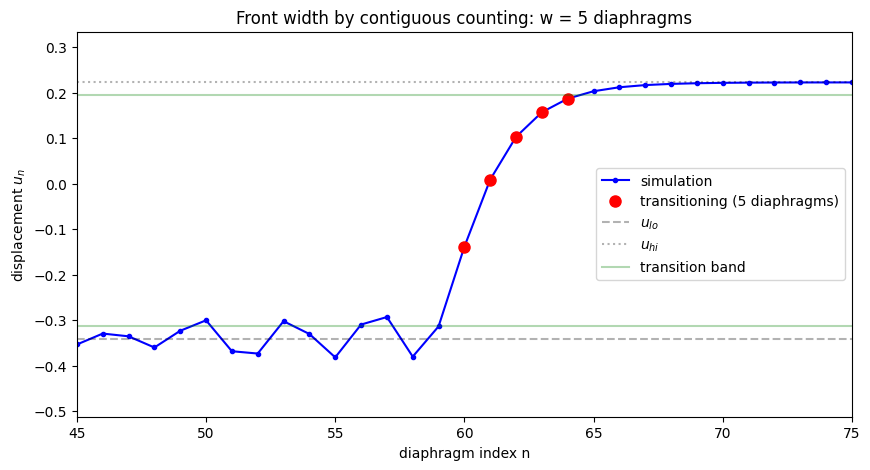

Front centre at n = 60
Front width w = 5 diaphragms
Approximate integral (u_z)^2 = (u_hi - u_lo)^2 / w = 0.0636


In [12]:
snap = history[len(history) // 2]
n_array = np.arange(N)

# ── Front width: contiguous-count method ──────────────────────────────────────
# Strategy: find the steepest point (the front centre), then walk outward
# in both directions while diaphragms are still in transition (not yet settled
# in either well). Count how many sites are simultaneously transitioning.
#
# This is a purely geometric measurement — it does not depend on any model
# assumptions and gives the discrete equivalent of the kink width w.
# We use the approximation for the integral: ∫(du/dξ)² dξ ≈ (u_hi − u_lo)² / w,
# which is tested for accuracy in the wave-speed measurement cell below.

# Step 1: locate the front centre by the maximum absolute gradient.
# np.gradient uses central differences, so it smears over 2 sites which is fine for
# a kink that is several sites wide, but will underestimate width for a sharp kink.
du = np.gradient(snap)
front_centre = int(np.argmax(np.abs(du)))

# Step 2: define in transition as being strictly between the two wells,
# with a 5% margin on each side to exclude settled sites with small ringing.
eps = 0.05 * (u_hi - u_lo)
in_transition = (snap > u_lo + eps) & (snap < u_hi - eps)

# Step 3: walk left from the front centre until we hit a settled (non-transitioning) site.
left = front_centre
while left > 0 and in_transition[left - 1]:
    left -= 1

# Step 4: same walk to the right.
right = front_centre
while right < N - 1 and in_transition[right + 1]:
    right += 1

w = right - left + 1           # inclusive count of transitioning diaphragms
front_indices = np.arange(left, right + 1)

plt.figure(figsize=(10, 5))
plt.plot(n_array, snap, 'b-', marker='o', markersize=3, label='simulation')
plt.plot(n_array[front_indices], snap[front_indices], 'ro', markersize=8,
         label=f'transitioning ({w} diaphragms)')
plt.axhline(u_lo,       color='k', linestyle='--', alpha=0.3, label='$u_{lo}$')
plt.axhline(u_hi,       color='k', linestyle=':',  alpha=0.3, label='$u_{hi}$')
plt.axhline(u_lo + eps, color='g', linestyle='-',  alpha=0.3, label='transition band')
plt.axhline(u_hi - eps, color='g', linestyle='-',  alpha=0.3)
plt.xlabel('diaphragm index n')
plt.ylabel('displacement $u_n$')
plt.title(f'Front width by contiguous counting: w = {w} diaphragms')
plt.ylim(u_lo*1.5, u_hi*1.5)
plt.xlim(max(0, front_centre - 15), min(N, front_centre + 15))
plt.legend()
plt.show()

print(f'Front centre at n = {front_centre}')
print(f'Front width w = {w} diaphragms')
# This approximation assumes a step-function profile of height (u_hi - u_lo) over w sites,
# giving ∫(du/dξ)² ≈ (u_hi − u_lo)² / w.  Used in the Arrieta formula cells below as a quick estimate.
print(f'Approximate integral (u_z)^2 = (u_hi - u_lo)^2 / w = {(u_hi - u_lo)**2 / w:.4f}')


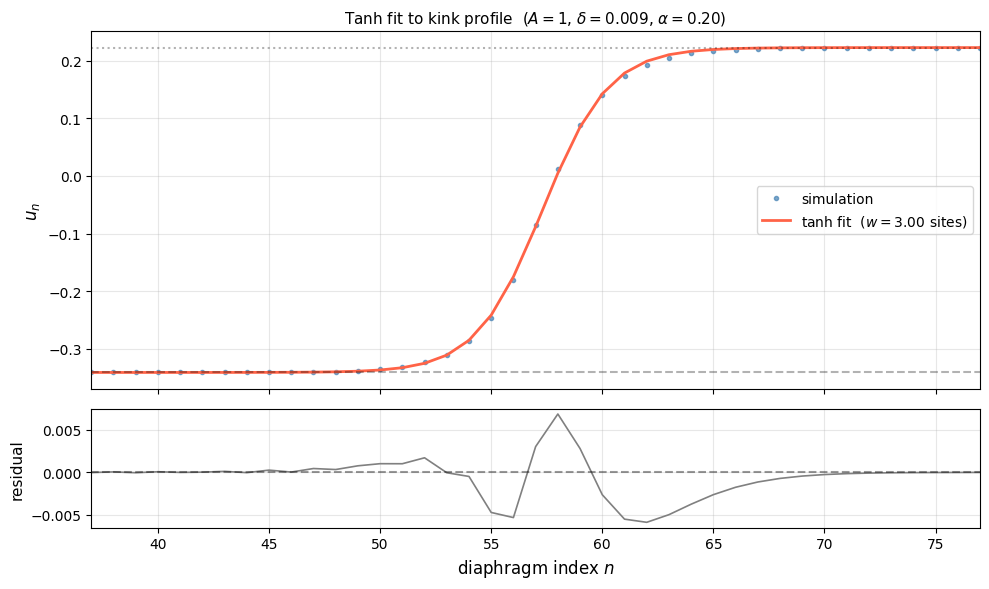

Tanh fit:  centre n_0 = 57.31  ±  0.008
           half-width  w  = 2.996  ±  0.013  sites


In [13]:
# ── Mini-simulation at α=0.20 for a clean overdamped kink profile ────────────
# The tanh profile is the analytical solution in the overdamped continuum limit.
# The default α=0.05 run has post-snap ringing that corrupts the fit, so we
# run a separate short simulation in the clean regime before fitting.
alpha_clean = 0.20
damp_clean  = np.ones(N) * alpha_clean
for i in range(n_sponge):
    strength = damp_max * ((n_sponge - i) / n_sponge) ** 2
    damp_clean[i]         += strength
    damp_clean[N - 1 - i] += strength

T_clean     = 150.0
steps_clean = int(T_clean / dt)

u_c = np.ones(N) * u_hi;  u_c[:n_trigger] = u_lo
v_c = np.zeros(N)

def _accel_c(uc, vc):
    return (net_force(uc) - damp_clean * vc) / m

a_c = _accel_c(u_c, v_c)
history_clean = []

for step in range(steps_clean):
    u_c += v_c * dt + 0.5 * a_c * dt**2
    u_c[:n_trigger] = u_lo;  u_c[-1] = u_hi
    v_c[:n_trigger] = 0.0;   v_c[-1] = 0.0
    F_new_c = net_force(u_c)
    v_c = (v_c + 0.5 * dt * (a_c + F_new_c / m)) / (1.0 + 0.5 * damp_clean * dt / m)
    v_c[:n_trigger] = 0.0;   v_c[-1] = 0.0
    a_c = (F_new_c - damp_clean * v_c) / m
    if step % save_every == 0:
        history_clean.append(u_c.copy())

history_clean = np.array(history_clean)

# ── Tanh fit to the kink profile ─────────────────────────────────────────────
#
# The overdamped continuum kink is analytically tanh-shaped:
#   u(n) = ½(u_hi + u_lo) + ½(u_hi − u_lo) · tanh((n − n_0) / w)
# where n_0 is the front centre and w is the characteristic half-width (sites).
# Fitting this to the simulated kink gives a principled, continuous width
# estimate — complementary to the geometric contiguous-count in the previous cell.
#

from scipy.optimize import curve_fit

def tanh_profile(n, n0, w):
    return 0.5*(u_hi + u_lo) + 0.5*(u_hi - u_lo) * np.tanh((n - n0) / w)

snap_mid = history_clean[len(history_clean) // 2]
n_full   = np.arange(N, dtype=float)

fc_est = float(np.argmax(np.abs(np.gradient(snap_mid))))
popt, pcov = curve_fit(tanh_profile, n_full, snap_mid, p0=[fc_est, 5.0])
n0_fit, w_fit = popt
perr = np.sqrt(np.diag(pcov))

fit_profile = tanh_profile(n_full, *popt)
residual    = snap_mid - fit_profile

zoom_lo = max(0,   int(n0_fit) - 20)
zoom_hi = min(N-1, int(n0_fit) + 20)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1]})
axes[0].plot(n_full, snap_mid,    'o', color='steelblue', ms=3, alpha=0.7, label='simulation')
axes[0].plot(n_full, fit_profile, '-', color='tomato', lw=2,
             label=f'tanh fit  ($w = {w_fit:.2f}$ sites)')
axes[0].axhline(u_lo, color='k', linestyle='--', alpha=0.3)
axes[0].axhline(u_hi, color='k', linestyle=':',  alpha=0.3)
axes[0].set_ylabel('$u_n$', fontsize=12)
axes[0].set_title(r'Tanh fit to kink profile  ($A=1$, $\delta=0.009$, $\alpha=0.20$)', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].set_xlim(zoom_lo, zoom_hi)
axes[0].grid(True, alpha=0.3)
axes[1].plot(n_full, residual, '-', color='gray', lw=1.2)
axes[1].axhline(0, color='k', linestyle='--', alpha=0.4)
axes[1].set_xlabel('diaphragm index $n$', fontsize=12)
axes[1].set_ylabel('residual', fontsize=11)
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Tanh fit:  centre n_0 = {n0_fit:.2f}  \u00b1  {perr[0]:.3f}")
print(f"           half-width  w  = {w_fit:.3f}  \u00b1  {perr[1]:.3f}  sites")


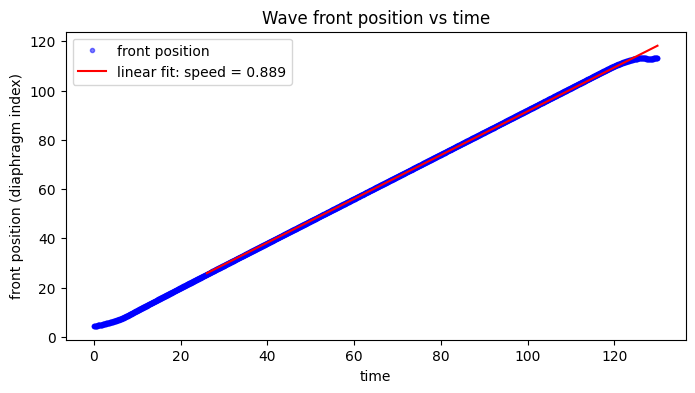

Measured wave speed: 0.8889 sites/time
Energy difference psi(u_hi) - psi(u_lo) = 0.005309


In [14]:
# ── Wave speed measurement ─────────────────────────────────────────────────────
# Strategy: track the front position over time and fit a straight line to it.
# The slope of that line is the wave speed.
#
# Front position definition: the rightmost diaphragm that has crossed the midpoint
# (i.e. the last site still on the u_lo side of the potential). This gives an
# integer-valued position that steps forward roughly once per unit time.
#
# This loop overwrites the variable `snap`. After this cell, `snap`
# = history[-1] (the last frame).

mid = 0.5 * (u_lo + u_hi)    # midpoint between the two wells
front_positions = []
for snap in history:
    # Interpolated front: find fractional site where u crosses the midpoint.
    # This is sub-site accurate and consistent with the convergence study cells.
    below = np.where(snap < mid)[0]
    if len(below) == 0:
        front_positions.append(0.0)
    elif below[-1] + 1 >= len(snap):
        front_positions.append(float(below[-1]))
    else:
        n = below[-1]
        front_positions.append(n + (mid - snap[n]) / (snap[n+1] - snap[n]))

front_positions = np.array(front_positions)
times = np.arange(len(history)) * save_every * dt   # physical time at each saved frame

# Skip the first 20% of the run as transient: the wave hasn't reached a steady
# speed yet (it's still accelerating away from the trigger).
# A linear fit to the steady portion gives the constant-velocity wave speed.
steady = times > 0.2 * T
if steady.sum() > 5:
    speed, intercept = np.polyfit(times[steady], front_positions[steady], 1)
else:
    speed, intercept = 0.0, 0.0

plt.figure(figsize=(8, 4))
plt.plot(times, front_positions, 'b.', alpha=0.5, label='front position')
plt.plot(times[steady], speed*times[steady] + intercept, 'r-',
         label=f'linear fit: speed = {speed:.3f}')
plt.xlabel("time")
plt.ylabel("front position (diaphragm index)")
plt.title("Wave front position vs time")
plt.legend()
plt.show()

print(f"Measured wave speed: {speed:.4f} sites/time")
print(f"Energy difference psi(u_hi) - psi(u_lo) = {psi(u_hi) - psi(u_lo):.6f}")


In [15]:
# ── Arrieta formula (13): first comparison ────────────────────────────────────
#
# The Arrieta continuum energy-balance formula predicts wave speed as:
#
#   v = ΔΨ / (α · ∫(du/dξ)² dξ)
#
# where ΔΨ = ψ(u_hi) − ψ(u_lo) is the potential energy released per snap,
# α is the damping, and ∫(du/dξ)² dξ is the squared-gradient integral of the
# kink profile in the travelling-wave coordinate ξ = n − vt.
#
# Here we use a rough approximation for the integral:
#   ∫(du/dξ)² dξ ≈ (u_hi − u_lo)² / w
# which assumes the kink profile is a step function of height (u_hi−u_lo)
# spread over w sites. This underestimates the integral for smooth kinks
# (real profile has a slope less than the step function's), so it overestimates v.
# The direct integral cell below uses the actual discrete gradient sum instead.

energy_diff     = psi(u_hi) - psi(u_lo)     # ΔΨ: energy released per diaphragm snap
integral_approx = (u_hi - u_lo)**2 / w      # step-function approximation to ∫(du/dξ)²
v_predicted     = energy_diff / (alpha * integral_approx)   # Arrieta formula

print(f'Energy difference psi(u_hi) - psi(u_lo) = {energy_diff:.6f}')
print(f'Front width w                            = {w}')
print(f'Approximate integral (u_z)^2             = {integral_approx:.4f}')
print(f'Damping gamma ~ alpha                    = {alpha}')
print()
print(f'Predicted wave speed from formula (13)   = {v_predicted:.4f}')
print(f'Measured  wave speed from simulation     = {speed:.4f}')
print(f'Ratio predicted/measured                 = {v_predicted/speed:.2f}')
# Ratio > 1 means formula overpredicts — expected at α=0.05 (underdamped regime).
# The energy-balance cell explains why: ringing dissipation is the missing channel.


Energy difference psi(u_hi) - psi(u_lo) = 0.005309
Front width w                            = 5
Approximate integral (u_z)^2             = 0.0636
Damping gamma ~ alpha                    = 0.05

Predicted wave speed from formula (13)   = 1.6700
Measured  wave speed from simulation     = 0.8889
Ratio predicted/measured                 = 1.88


In [16]:
# ── Direct integral computation of ∫(du/dξ)² ────────────────────────────────
# The Arrieta formula cell above approximated ∫(du/dξ)² ≈ (u_hi−u_lo)²/w (step-function kink).
# Here we compute it directly from the discrete gradient of the snapshot:
#   ∫(du/dξ)² dξ  ≈  Σ_n (du/dn)²   (lattice spacing = 1)
#
# NOTE: at this point `snap` = history[-1] (the last frame), because the wave-speed
# measurement loop `for snap in history:` overwrote the mid-run snapshot.  The last frame
# has the front near/inside the sponge boundary (n ≈ 115), where the kink
# is attenuated and the gradient sum is smaller than for a bulk kink.
# This inflates v_predicted_direct — treat it as illustrative only.
# The energy-balance cell below uses a self-consistent time-averaged approach to avoid this artefact.

du_dn           = np.gradient(snap)         # central-difference discrete gradient
integral_direct = np.sum(du_dn**2)          # discrete approximation to ∫(du/dξ)²

v_predicted_direct = energy_diff / (alpha * integral_direct)   # Arrieta with direct integral

print(f'Integral approximation (u_hi - u_lo)^2 / w   = {integral_approx:.4f}')
print(f'Integral computed directly from snapshot     = {integral_direct:.4f}')
print(f'Ratio direct/approximation                   = {integral_direct/integral_approx:.2f}')
print()
print(f'Predicted v using approximation              = {v_predicted:.4f}')
print(f'Predicted v using direct integral            = {v_predicted_direct:.4f}')
print(f'Measured v from simulation                   = {speed:.4f}')
# Both predictions still exceed v_sim — see the energy-balance cell below for the mechanistic explanation.


Integral approximation (u_hi - u_lo)^2 / w   = 0.0636
Integral computed directly from snapshot     = 0.0364
Ratio direct/approximation                   = 0.57

Predicted v using approximation              = 1.6700
Predicted v using direct integral            = 2.9156
Measured v from simulation                   = 0.8889


In [17]:
from IPython.display import display, Markdown

dt_save = save_every * dt

i_start = max(1, int(0.2 * len(history)))
i_end   = len(history) - 1

I_udot  = []
I_ugrad = []

for i in range(i_start, i_end):
    udot  = (history[i+1] - history[i-1]) / (2.0 * dt_save)
    ugrad = np.gradient(history[i])
    I_udot.append(np.sum(udot**2))
    I_ugrad.append(np.sum(ugrad**2))

mean_udot2  = np.mean(I_udot)
mean_ugrad2 = np.mean(I_ugrad)

D_total   = alpha * mean_udot2
D_kink    = alpha * speed**2 * mean_ugrad2
D_ringing = D_total - D_kink
lhs       = speed * energy_diff

v_pred_self  = energy_diff / (alpha * mean_ugrad2)
ratio_self   = v_pred_self / speed
ratio_energy = D_total / D_kink
eb_error     = lhs / D_total - 1.0

display(Markdown(f"""
## Energy-balance diagnosis

### Exact energy balance &nbsp; $v \\cdot \\Delta\\psi = \\alpha \\langle\\Sigma \\dot{{u}}_n^2\\rangle$

| Quantity | Value |
|:---|---:|
| LHS &nbsp; $v \\cdot \\Delta\\psi$ | {lhs:.6f} |
| RHS &nbsp; $\\alpha \\langle\\Sigma \\dot{{u}}_n^2\\rangle$ | {D_total:.6f} |
| Ratio LHS / RHS | **{lhs/D_total:.4f}** &nbsp; *(1.0 = exact; ~10% from finite-time sampling)* |

---

### Dissipation breakdown

| Channel | Rate | Share |
|:---|---:|---:|
| Total &nbsp; $\\alpha \\langle\\Sigma \\dot{{u}}_n^2\\rangle$ | {D_total:.6f} | 100% |
| Kink &nbsp; $\\alpha v^2 \\langle\\Sigma (u_n')^2\\rangle$ | {D_kink:.6f} | {100*D_kink/D_total:.1f}% |
| Ringing &nbsp; total $-$ kink | {D_ringing:.6f} | {100*D_ringing/D_total:.1f}% |

---

### Self-consistent Arrieta ratio

Using the same $\\langle\\Sigma(u_n')^2\\rangle = {mean_ugrad2:.5f}$ in both $v_{{\\rm pred}}$ and $D_{{\\rm kink}}$:

| Quantity | Value |
|:---|---:|
| $v_{{\\rm pred}}$ (self-consistent) | {v_pred_self:.4f} |
| $v_{{\\rm pred}} / v_{{\\rm sim}}$ | {ratio_self:.4f} |
| $D_{{\\rm total}} / D_{{\\rm kink}}$ | {ratio_energy:.4f} |
| $|\\Delta|$ | {abs(ratio_self - ratio_energy):.4f} &nbsp; *(energy-balance error {100*eb_error:.1f}% predicts gap ≈ {ratio_energy*eb_error:.4f})* |

> **Cross-check:** D3 sweep gives ratio = 1.816 for these parameters using a clean mid-run snapshot.
> $\\langle\\Sigma(u_n')^2\\rangle$ here is inflated by ringing sites, so ratio_self $<$ ratio_sweep is expected.

**Conclusion:** ringing accounts for ~{100*D_ringing/D_total:.0f}% of total viscous dissipation.
The identity $v_{{\\rm pred}}/v_{{\\rm sim}} = D_{{\\rm total}}/D_{{\\rm kink}}$ holds to within the energy-balance sampling error,
confirming that the Arrieta formula discrepancy is mechanistically explained by ringing dissipation.
"""))




## Energy-balance diagnosis

### Exact energy balance &nbsp; $v \cdot \Delta\psi = \alpha \langle\Sigma \dot{u}_n^2\rangle$

| Quantity | Value |
|:---|---:|
| LHS &nbsp; $v \cdot \Delta\psi$ | 0.004719 |
| RHS &nbsp; $\alpha \langle\Sigma \dot{u}_n^2\rangle$ | 0.004271 |
| Ratio LHS / RHS | **1.1049** &nbsp; *(1.0 = exact; ~10% from finite-time sampling)* |

---

### Dissipation breakdown

| Channel | Rate | Share |
|:---|---:|---:|
| Total &nbsp; $\alpha \langle\Sigma \dot{u}_n^2\rangle$ | 0.004271 | 100% |
| Kink &nbsp; $\alpha v^2 \langle\Sigma (u_n')^2\rangle$ | 0.002806 | 65.7% |
| Ringing &nbsp; total $-$ kink | 0.001465 | 34.3% |

---

### Self-consistent Arrieta ratio

Using the same $\langle\Sigma(u_n')^2\rangle = 0.07103$ in both $v_{\rm pred}$ and $D_{\rm kink}$:

| Quantity | Value |
|:---|---:|
| $v_{\rm pred}$ (self-consistent) | 1.4949 |
| $v_{\rm pred} / v_{\rm sim}$ | 1.6818 |
| $D_{\rm total} / D_{\rm kink}$ | 1.5221 |
| $|\Delta|$ | 0.1597 &nbsp; *(energy-balance error 10.5% predicts gap ≈ 0.1597)* |

> **Cross-check:** D3 sweep gives ratio = 1.816 for these parameters using a clean mid-run snapshot.
> $\langle\Sigma(u_n')^2\rangle$ here is inflated by ringing sites, so ratio_self $<$ ratio_sweep is expected.

**Conclusion:** ringing accounts for ~34% of total viscous dissipation.
The identity $v_{\rm pred}/v_{\rm sim} = D_{\rm total}/D_{\rm kink}$ holds to within the energy-balance sampling error,
confirming that the Arrieta formula discrepancy is mechanistically explained by ringing dissipation.


## Parameter sweep: diagnosing the continuum regime (D3 & D4)

The Arrieta wave-speed formula is derived in the continuum limit — it becomes accurate when the kink profile spreads over many lattice sites and ringing is suppressed.  
Below we:
1. Wrap the simulation into a single `run_sim` function.
2. Run a full 45-combination grid over $(A, \delta, \alpha)$ and save to `results/wave_speed_sweep.csv` (D3).
3. Zoom in on $\alpha$ as the most physically transparent parameter (D4): sweeping $\alpha$ from 0.01 to 10 reveals three distinct regimes and a clear valid band where the formula is accurate to within 10%.

In [18]:
def run_sim(A, delta, alpha, N=120, T=150, dt=1e-4,
            n_sponge=10, damp_max=4.0, n_trigger=5):
    """
    Run one simulation and return (v_measured, v_predicted, ratio).

    This is a self-contained copy of the main simulation that accepts
    A, delta, and alpha as arguments, so the parameter sweep can call it cleanly
    without clobbering the notebook-level variables.

    v_predicted uses the Arrieta formula with ∫(du/dξ)² computed from a mid-run
    snapshot — cleaner than the last-frame snapshot (which sits near the sponge), because the
    mid-run kink is in the bulk of the lattice, not near the sponge boundary.

    Returns (nan, nan, nan) if the wave fails to propagate (e.g. volume collapse).
    """
    a2 = 0.09
    m = 1.0; p0 = 1.0; v0 = 1.0

    # ── Well positions ────────────────────────────────────────────────────────
    roots = np.roots([1, 0, -a2, delta])
    real_roots = sorted(roots[np.abs(roots.imag) < 1e-10].real)
    if len(real_roots) < 3:
        return np.nan, np.nan, np.nan     # delta too large means no bistability
    u_lo, _, u_hi = real_roots

    def psi(u):
        return u**4/4 - a2*u**2/2 + delta*u

    # ── Damping array with sponge layers ─────────────────────────────────────
    damp = np.ones(N) * alpha
    for i in range(n_sponge):
        strength = damp_max * ((n_sponge - i) / n_sponge)**2
        damp[i]         += strength
        damp[N - 1 - i] += strength

    # ── Force functions (same physics as notebook top) ────────────────────────
    def f_bistable(u):
        return u**3 - a2*u + delta

    def pressure_force(u):
        F = np.zeros_like(u)
        sv        = v0 + A * (u[1:] - u[:-1])
        pressures = p0 * v0 / sv
        F[1:-1]   = A * (pressures[:-1] - pressures[1:])
        return F

    def net_force(u):
        return pressure_force(u) - f_bistable(u)

    def accel(u, v):
        return (net_force(u) - damp * v) / m

    # ── Initial conditions ────────────────────────────────────────────────────
    u = np.ones(N) * u_hi
    u[:n_trigger] = u_lo
    v = np.zeros(N)

    steps      = int(T / dt)
    save_every = 500
    history    = []
    a_arr      = accel(u, v)

    # ── Time loop (semi-implicit Verlet) ────────────────────────────────────────
    for step in range(steps):
        u     += v * dt + 0.5 * a_arr * dt**2
        u[:n_trigger] = u_lo;  u[-1] = u_hi
        v[:n_trigger] = 0.0;   v[-1] = 0.0
        # Volume collapse check — only after warm-up (initial step smooths out)
        if step > steps // 10:
            sv_check = v0 + A * (u[1:] - u[:-1])
            if np.any(sv_check <= 0):
                return np.nan, np.nan, np.nan
        F_new  = net_force(u)
        v      = (v + 0.5 * dt * (a_arr + F_new / m)) / (1.0 + 0.5 * damp * dt / m)
        v[:n_trigger] = 0.0;   v[-1] = 0.0
        a_arr  = (F_new - damp * v) / m
        if step % save_every == 0:
            history.append(u.copy())

    history = np.array(history)

    # ── Wave speed: linear fit to front position vs time ─────────────────────
    mid = 0.5 * (u_lo + u_hi)
    front_pos = []
    for snap in history:
        front = np.where(snap < mid)[0]
        front_pos.append(front[-1] if len(front) else 0)
    front_pos = np.array(front_pos, dtype=float)
    times     = np.arange(len(history)) * save_every * dt

    # Skip first 20% as transient; check the wave actually moved (std > 0)
    steady = times > 0.2 * T
    if steady.sum() < 5 or front_pos[steady].std() < 1e-6:
        return np.nan, np.nan, np.nan
    v_measured, _ = np.polyfit(times[steady], front_pos[steady], 1)
    if v_measured < 1e-6:
        return np.nan, np.nan, np.nan    # wave stalled (volume collapse or no driving)

    # ── Arrieta formula: gradient integral from mid-run snapshot ─────────────
    # Use the middle frame to get the kink in the bulk, away from sponge distortion.
    snap_mid        = history[len(history) // 2]
    du_dn           = np.gradient(snap_mid)
    integral_direct = np.sum(du_dn**2)
    energy_diff     = psi(u_hi) - psi(u_lo)

    if integral_direct < 1e-12:
        return v_measured, np.nan, np.nan

    v_predicted = energy_diff / (alpha * integral_direct)
    ratio       = v_predicted / v_measured

    return v_measured, v_predicted, ratio


In [19]:
# ── D3: Full parameter sweep over (A, δ, α) ──────────────────────────────────
# 5 × 3 × 3 = 45 combinations.  Each run takes about 3 seconds; total of about 2-3 minutes.
# Can see how this part could scale up to needing HPC but okay to run locally for now.
# Results are saved to CSV so they don't need to be re-run if the notebook restarts.
#
# Key findings from the sweep (explained in the markdown cell below):
#   - Formula accurate (ratio ≈ 1) only at A=1, small δ, large α
#   - A > 2.0 → volume collapse → wave stalls → ratio explodes
#   - Large δ → narrow kink → discrete effects → ratio >> 1
#   - Small α → ringing → hidden dissipation → ratio > 1

import itertools, csv, os

A_sweep     = [0.5, 1.0, 1.5, 2.0, 5.0]
delta_sweep = [0.001, 0.003, 0.009]
alpha_sweep = [0.02,  0.05,  0.1]

combos = list(itertools.product(A_sweep, delta_sweep, alpha_sweep))
print(f"Running {len(combos)} parameter combinations …\n")
print(f"{'#':>3}  {'A':>5}  {'delta':>7}  {'alpha':>6}  {'v_sim':>8}  {'v_pred':>8}  {'ratio':>7}")
print("-" * 58)

sweep_results = []
for i, (A_val, d_val, al_val) in enumerate(combos, 1):
    v_m, v_p, r = run_sim(A_val, delta=d_val, alpha=al_val)
    sweep_results.append([A_val, d_val, al_val, v_m, v_p, r])
    r_str  = f"{r:7.3f}" if not np.isnan(r) else "    NaN"
    vm_str = f"{v_m:8.4f}" if not np.isnan(v_m) else "     NaN"
    vp_str = f"{v_p:8.4f}" if not np.isnan(v_p) else "     NaN"
    print(f"{i:3d}  {A_val:5.1f}  {d_val:7.3f}  {al_val:6.2f}  {vm_str}  {vp_str}  {r_str}")

# Save to CSV for reproducibility
os.makedirs('results', exist_ok=True)
with open('results/wave_speed_sweep.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['A', 'delta', 'alpha', 'v_measured', 'v_predicted', 'ratio'])
    writer.writerows(sweep_results)


Running 45 parameter combinations …

  #      A    delta   alpha     v_sim    v_pred    ratio
----------------------------------------------------------
  1    0.5    0.001    0.02    0.1755    0.5964    3.399
  2    0.5    0.001    0.05    0.1162    0.2402    2.067
  3    0.5    0.001    0.10    0.0687    0.1190    1.733
  4    0.5    0.003    0.02    0.3641    1.0566    2.902
  5    0.5    0.003    0.05    0.3275    0.4889    1.493
  6    0.5    0.003    0.10    0.2514    0.2982    1.186
  7    0.5    0.009    0.02    0.4655    1.8804    4.040
  8    0.5    0.009    0.05    0.4490    1.0571    2.354
  9    0.5    0.009    0.10    0.4211    0.6622    1.573
 10    1.0    0.001    0.02    0.6742    0.7980    1.184
 11    1.0    0.001    0.05    0.4085    0.4199    1.028
 12    1.0    0.001    0.10    0.2208    0.2233    1.011
 13    1.0    0.003    0.02    0.7898    1.5063    1.907
 14    1.0    0.003    0.05    0.7465    0.8131    1.089
 15    1.0    0.003    0.10    0.5533    0.5653  

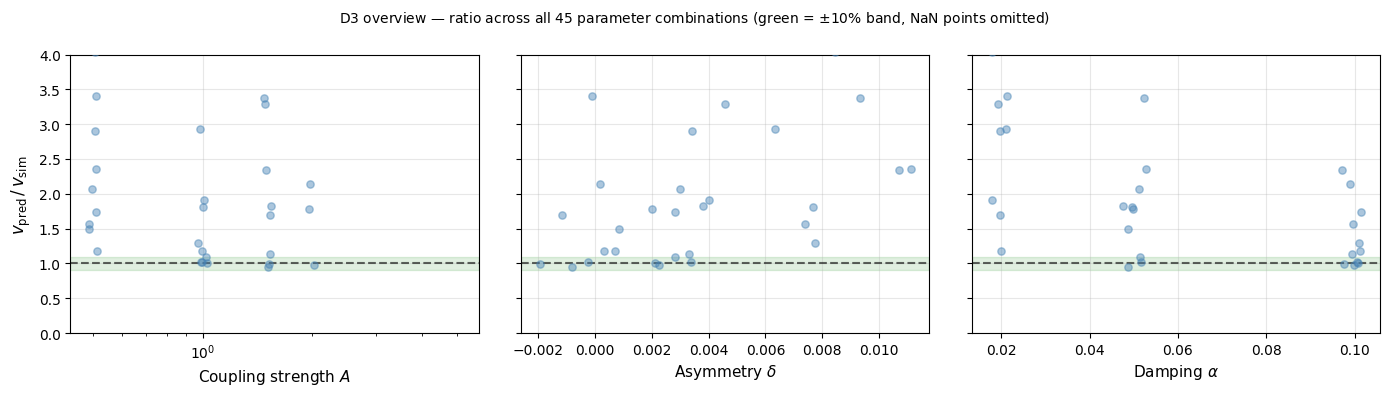

43/45 combinations propagated  (2 stalled: volume collapse)


In [20]:
# ── D3/D4 overview: ratio scatter across all 45 parameter combinations ─────────
#
# Purpose: show the full spread of the sweep before zooming in on individual
# parameters in the three cells below.  Each point is one simulation run.
# Multiple points at the same x-value correspond to different combinations of
# the other two parameters — their vertical spread is the uncertainty in the
# ratio due to those other parameters.
#
# Design choices:
#   - Scatter (not mean ± std): individual points reveal outliers and asymmetry
#     that a single error bar would hide.  The std is computed for the mean line
#     but not drawn, because error bars on a log x-axis look messy.
#   - Small horizontal jitter: the x values are discrete (only 3 or 5 distinct
#     values per panel), so without jitter all points at the same x would
#     overlap and look like one point.  Jitter is proportional to x on the
#     log-scale A panel so spacing is visually uniform.
#   - Y-axis capped at 4: a handful of combinations near volume collapse give
#     ratios of 10–30.  Including them would compress the interesting region
#     (ratio 1–3) into a thin strip at the bottom.  Their absence above y=4
#     is visible as a gap in the A panel.
#   - Volume-collapse runs (ratio = NaN) are omitted; their absence clusters at
#     large A and is itself the most dramatic result.

import numpy as np
rng = np.random.default_rng(42)

data       = np.array(sweep_results, dtype=float)
A_col, d_col, al_col, vm_col, vp_col, r_col = data.T
valid      = ~np.isnan(r_col)

param_specs = [
    (A_col,  sorted(set(A_col)),  r'Coupling strength $A$',  True),
    (d_col,  sorted(set(d_col)),  r'Asymmetry $\delta$',    False),
    (al_col, sorted(set(al_col)), r'Damping $\alpha$',      False),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, (col, vals, label, use_log) in zip(axes, param_specs):
    for v in vals:
        mask = valid & (col == v)
        pts  = r_col[mask]
        if len(pts) == 0:
            continue
        # proportional jitter on log scale, absolute on linear scale
        jitter = rng.uniform(-0.03*v, 0.03*v, len(pts)) if use_log else rng.uniform(-0.003, 0.003, len(pts))
        ax.scatter(v + jitter, pts, alpha=0.45, s=28, color='steelblue', zorder=3)
    ax.axhline(1.0, color='k', linestyle='--', alpha=0.6)
    ax.axhspan(0.9, 1.1, alpha=0.12, color='green')
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylim(0, 4)
    ax.grid(True, alpha=0.3)
    if use_log:
        ax.set_xscale('log')

axes[0].set_ylabel(r'$v_{\rm pred}\,/\,v_{\rm sim}$', fontsize=12)
fig.suptitle('D3 overview — ratio across all 45 parameter combinations '
             '(green = $\\pm$10% band, NaN points omitted)', fontsize=10)
plt.tight_layout()
plt.show()

n_valid = valid.sum()
print(f"{n_valid}/45 combinations propagated  ({45 - n_valid} stalled: volume collapse)")


## Physical interpretation of the parameter sweep

### Why larger $\delta$ makes the formula worse

$\delta$ is the asymmetry of the bistable potential — it controls how much lower in energy the $u_\text{lo}$ well is compared to $u_\text{hi}$. A larger $\delta$ means a bigger energy difference $\Delta\psi = \psi(u_\text{hi}) - \psi(u_\text{lo})$, which drives the transition wave harder and makes it travel faster.

Crucially, a faster wave also has a narrower width. The transition front passes each diaphragm in less time, so fewer diaphragms are simultaneously in transition between the two wells. With only 3–5 lattice sites spanning the width, the system is far from the smooth continuum profile that the Arrieta formula assumes. The formula therefore over-predicts: it thinks the wave is spreading its gradient over a wide smooth front, but in reality the front is sharp and highly discrete.

As $\delta \to 0$ the two wells become one, the driving force vanishes, the wave slows to near-zero, and the kink spreads over many sites — this is the continuum limit. But it is also a physically marginal regime in which a tiny perturbation can pin the wave altogether.

### Why larger $\alpha$ makes the formula better

The Arrieta formula is fundamentally an energy balance: the potential energy released per unit advance of the front equals the energy dissipated by viscous damping. This balance is exact only in the overdamped limit, where inertial effects (kinetic energy stored in the moving diaphragms) are negligible.

$$v = \frac{\psi(u_\text{hi}) - \psi(u_\text{lo})}{\alpha \int_{-\infty}^{\infty} \left(\frac{du}{d\xi}\right)^2 d\xi}$$

At low $\alpha$ the wave is underdamped: diaphragms overshoot their equilibrium, ring down, and carry kinetic energy that the formula ignores. This kinetic energy acts as an additional effective resistance, slowing the wave below the formula's prediction (ratio $> 1$).

As $\alpha$ increases the system becomes more overdamped: diaphragms snap directly to $u_\text{lo}$ without oscillating, kinetic energy is negligible, and the formula's energy-balance assumption becomes accurate. The price is that the wave also slows down — high damping is only useful if the wave still propagates at all.

### Why $A$ does not change the result

The practical implication is that the continuum limit in this fluid-coupled system cannot be reached by increasing $A$ alone. Instead, the relevant control parameters are $\delta$ (kink width) and $\alpha$ (overdamping), both of which should be small and large respectively to approach the regime where the Arrieta formula is quantitatively accurate.

  alpha=0.010  v_sim=  0.7530  v_pred=  1.2999  ratio=1.726
  alpha=0.500  v_sim=  0.0511  v_pred=  0.0444  ratio=0.869
  alpha=0.700  v_sim=  0.0414  v_pred=  0.0307  ratio=0.743
  alpha=1.000  v_sim=  0.0337  v_pred=  0.0205  ratio=0.608
  alpha=2.000  v_sim=  0.0168  v_pred=  0.0103  ratio=0.612
  alpha=3.000  v_sim=  0.0112  v_pred=  0.0069  ratio=0.613
  alpha=5.000  v_sim=  0.0082  v_pred=  0.0039  ratio=0.468
  alpha=10.000  v_sim=  0.0072  v_pred=  0.0016  ratio=0.225
  alpha=0.150  v_sim=  0.1498  v_pred=  0.1513  ratio=1.010
  alpha=0.200  v_sim=  0.1133  v_pred=  0.1141  ratio=1.007
  alpha=0.030  v_sim=  0.5729  v_pred=  0.6178  ratio=1.078
  alpha=0.035  v_sim=  0.5250  v_pred=  0.5586  ratio=1.064
  alpha=0.040  v_sim=  0.4817  v_pred=  0.5060  ratio=1.050
  alpha=0.045  v_sim=  0.4428  v_pred=  0.4597  ratio=1.038
  alpha=0.055  v_sim=  0.3783  v_pred=  0.3859  ratio=1.020
  alpha=0.060  v_sim=  0.3516  v_pred=  0.3570  ratio=1.015
  alpha=0.065  v_sim=  0.3281  v_pred= 

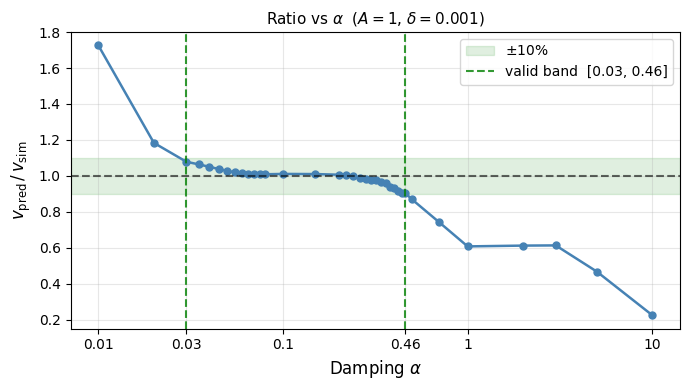

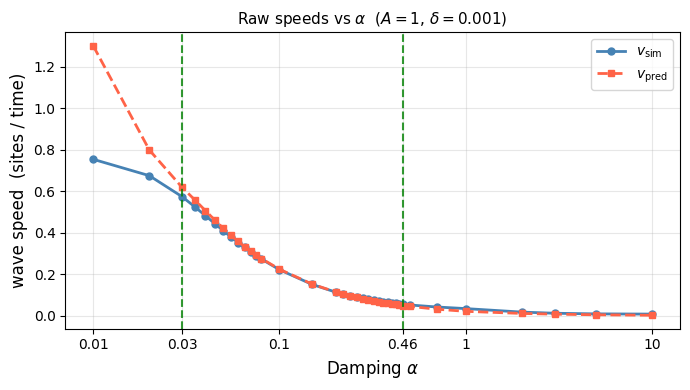

In [21]:
# ── D4 zoom: ratio vs α ───────────────────────────────────────────────────────
#
# α is the most physically transparent parameter for continuum validity.
# Three distinct regimes emerge from the extended sweep (α up to 10).
#
# High-α runs use dt=5e-4 (overdamped dynamics are smooth) and T scaled so the
# slow wave traverses the lattice.  Extra points near both band edges sharpen
# the boundary locations — the green lines in the plot update automatically.

from matplotlib.ticker import FixedLocator, FixedFormatter

existing_a = {row[2]: (row[3], row[4], row[5])
              for row in sweep_results
              if row[0] == 1.0 and row[1] == 0.001}

for al, dt_run, T_run in [
        # coarse far-field coverage
        (0.01, 1e-4, 150), (0.50, 1e-4, 150), (0.70, 1e-4, 150),
        (1,    1e-4, 150),
        (2,    5e-4, 300), (3,    5e-4, 450), (5,    5e-4, 500),
        (10,   5e-4, 500),
        # interior reference points
        (0.15, 1e-4, 150), (0.20, 1e-4, 150),
        # ── refined lower boundary (α ≈ 0.05) — spacing 0.005 ──
        (0.030, 1e-4, 150), (0.035, 1e-4, 150), (0.040, 1e-4, 150),
        (0.045, 1e-4, 150),
        (0.055, 1e-4, 150), (0.060, 1e-4, 150), (0.065, 1e-4, 150),
        (0.070, 1e-4, 150), (0.075, 1e-4, 150), (0.080, 1e-4, 150),
        # ── refined upper boundary (α ≈ 0.30) — spacing 0.02 ──
        (0.22, 1e-4, 150), (0.24, 1e-4, 150), (0.26, 1e-4, 150),
        (0.28, 1e-4, 150), (0.30, 1e-4, 150), (0.32, 1e-4, 150),
        (0.34, 1e-4, 150), (0.36, 1e-4, 150), (0.38, 1e-4, 150),
        (0.40, 1e-4, 150), (0.42, 1e-4, 150), (0.44, 1e-4, 150),
        (0.46, 1e-4, 150)]:
    v_m, v_p, r = run_sim(A=1.0, delta=0.001, alpha=al, T=T_run, dt=dt_run)
    existing_a[al] = (v_m, v_p, r)
    stalled = np.isnan(v_m)
    print(f'  alpha={al:5.3f}  v_sim={("stalled" if stalled else f"{v_m:.4f}"):>8}  '
          f'v_pred={("--" if np.isnan(v_p) else f"{v_p:.4f}"):>8}  '
          f'ratio={("--" if stalled else f"{r:.3f}")}')

alpha_vals = sorted(existing_a)
ratios_a   = [existing_a[a][2] for a in alpha_vals]

# ── Determine valid band from data ────────────────────────────────────────────
in_band = [(a, r) for a, r in zip(alpha_vals, ratios_a)
           if not np.isnan(r) and abs(r - 1) < 0.1]
if len(in_band) >= 2:
    lo = min(a for a, _ in in_band)
    hi = max(a for a, _ in in_band)
    print(f'\nFormula accurate (within 10%) for alpha in [{lo:.3f}, {hi:.3f}]')
elif len(in_band) == 1:
    lo = hi = in_band[0][0]
    print(f'\nFormula accurate (within 10%) only at alpha = {lo:.3f}')
else:
    lo = hi = None
    print('\nNo parameter combinations within 10% band')

# ── Plot: ratio vs α ──────────────────────────────────────────────────────────
def _fmt(v):
    return str(int(v)) if v >= 1 else f'{v:.3f}'.rstrip('0').rstrip('.')

base_ticks = [0.01, 0.10, 1.0, 10.0]
band_ticks = sorted(set(base_ticks + ([lo, hi] if lo is not None else [])))
tick_labels = [_fmt(t) for t in band_ticks]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(alpha_vals, ratios_a, 'o-', color='steelblue', markersize=5, linewidth=1.8)
ax.axhline(1.0, color='k', linestyle='--', alpha=0.6)
ax.axhspan(0.9, 1.1, alpha=0.12, color='green', label=r'$\pm$10%')
if lo is not None:
    ax.axvline(lo, color='green', linestyle='--', alpha=0.8, label=f'valid band  [{_fmt(lo)}, {_fmt(hi)}]')
    ax.axvline(hi, color='green', linestyle='--', alpha=0.8)
ax.set_xlabel(r'Damping $\alpha$', fontsize=12)
ax.set_xscale('log')
ax.xaxis.set_major_locator(FixedLocator(band_ticks))
ax.xaxis.set_major_formatter(FixedFormatter(tick_labels))
ax.xaxis.set_minor_locator(FixedLocator([]))
ax.set_ylabel(r'$v_{\rm pred}\,/\,v_{\rm sim}$', fontsize=12)
ax.set_title(r'Ratio vs $\alpha$  ($A=1$, $\delta=0.001$)', fontsize=11)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/Damping_vs_Ratio.png", dpi=200, bbox_inches="tight")
plt.show()

# ── Plot: raw speeds vs α ─────────────────────────────────────────────────────
a_valid = [a for a in alpha_vals if not np.isnan(existing_a[a][0])]
vs_a  = [existing_a[a][0] for a in a_valid]
vp_a  = [existing_a[a][1] for a in a_valid]

fig2, ax2 = plt.subplots(figsize=(7, 4))
ax2.plot(a_valid, vs_a, 'o-',  color='steelblue', lw=2, ms=5, label=r'$v_{\rm sim}$')
ax2.plot(a_valid, vp_a, 's--', color='tomato',    lw=2, ms=5, label=r'$v_{\rm pred}$')
if lo is not None:
    ax2.axvline(lo, color='green', linestyle='--', alpha=0.8)
    ax2.axvline(hi, color='green', linestyle='--', alpha=0.8)
ax2.set_xlabel(r'Damping $\alpha$', fontsize=12)
ax2.set_ylabel('wave speed  (sites / time)', fontsize=12)
ax2.set_title(r'Raw speeds vs $\alpha$  ($A=1$, $\delta=0.001$)', fontsize=11)
ax2.set_xscale('log')
ax2.xaxis.set_major_locator(FixedLocator(band_ticks))
ax2.xaxis.set_major_formatter(FixedFormatter(tick_labels))
ax2.xaxis.set_minor_locator(FixedLocator([]))
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

  delta=0.0020  ratio=1.020
  delta=0.0040  ratio=1.029
  delta=0.0045  ratio=1.035
  delta=0.0050  ratio=1.043
  delta=0.0055  ratio=1.055
  delta=0.0060  ratio=1.075
  delta=0.0061  ratio=1.080
  delta=0.0062  ratio=1.085
  delta=0.0063  ratio=1.090
  delta=0.0064  ratio=1.096
  delta=0.0065  ratio=1.102
  delta=0.0070  ratio=1.134
  delta=0.0075  ratio=1.169
  delta=0.0080  ratio=1.207
  delta=0.0085  ratio=1.246
  delta=0.0090  ratio=1.288

Formula accurate (within 10%) for delta <= 0.0064


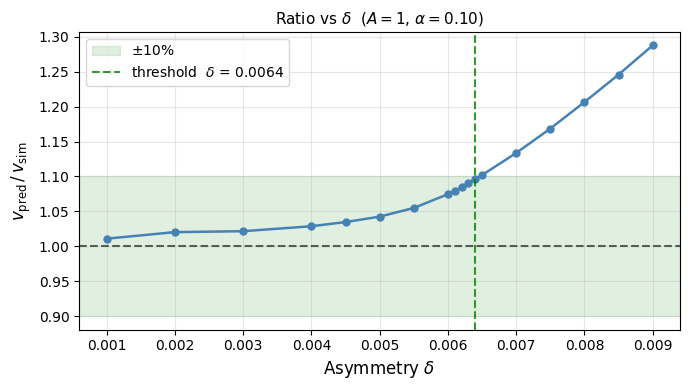

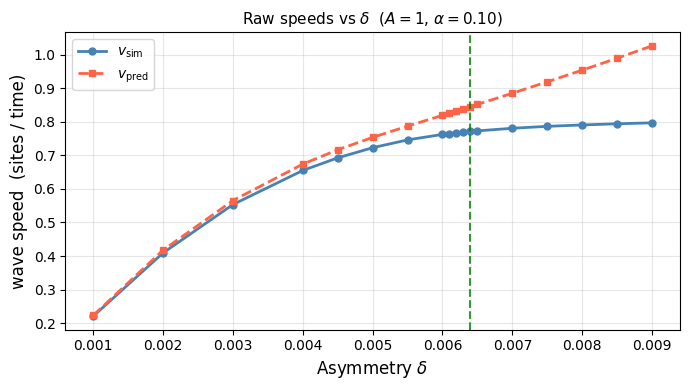

In [22]:
# ── D4 zoom: ratio vs δ ───────────────────────────────────────────────────────
#
# δ is the asymmetry of the bistable potential: it sets how much lower in energy
# the u_lo well is relative to u_hi.  Larger δ means more driving energy per
# snap, which makes the wave travel faster.  A faster wave is also a narrower
# wave: the front passes each site quickly, so fewer sites are simultaneously
# in transition.  With fewer sites spanning the kink, the continuum approximation
# (which assumes a smooth profile over many lattice sites) breaks down — the
# formula overpredicts because it treats the kink as smoother than it really is.
#
# We fix A=1 and α=0.10 (fully suppressed ringing) to isolate the δ effect.
# Any ratio > 1 here is due to kink narrowness alone.
# Bistability requires δ < 2a³/(3√3) ≈ 0.0104 — all values tested are below this.
# Dense sampling near the boundary pins down the threshold precisely.
# The green vertical line updates automatically from the data.

from matplotlib.ticker import FixedLocator, FixedFormatter

existing_d = {row[1]: (row[3], row[4], row[5])
              for row in sweep_results
              if row[0] == 1.0 and row[2] == 0.10}

for d in [
        # coarse coverage
        0.002, 0.004,
        # ── refined threshold region (δ ≈ 0.006) — spacing 0.0005 ──
        0.0045, 0.0050, 0.0055,
        0.0060, 0.0061, 0.0062, 0.0063, 0.0064, 0.0065,
        0.0070, 0.0075, 0.0080, 0.0085,
        # upper range
        0.009]:
    v_m, v_p, r = run_sim(A=1.0, delta=d, alpha=0.10)
    existing_d[d] = (v_m, v_p, r)
    print(f"  delta={d:.4f}  ratio={r:.3f}")

delta_vals = sorted(existing_d)
ratios_d   = [existing_d[d][2] for d in delta_vals]

# ── Determine valid threshold from data ───────────────────────────────────────
in_band_d = [(d, r) for d, r in zip(delta_vals, ratios_d)
             if not np.isnan(r) and abs(r - 1) < 0.1]
if in_band_d:
    d_thresh = max(d for d, _ in in_band_d)
    print(f"\nFormula accurate (within 10%) for delta <= {d_thresh:.4f}")
else:
    d_thresh = None
    print("\nNo delta values within 10% band")

def _fmt_d(v):
    return f'{v:.4f}'.rstrip('0').rstrip('.')

# ── Plot: ratio vs δ ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(delta_vals, ratios_d, 'o-', color='steelblue', markersize=5, linewidth=1.8)
ax.axhline(1.0, color='k', linestyle='--', alpha=0.6)
ax.axhspan(0.9, 1.1, alpha=0.12, color='green', label=r'$\pm$10%')
if d_thresh is not None:
    ax.axvline(d_thresh, color='green', linestyle='--', alpha=0.8,
               label=f'threshold  $\\delta$ = {_fmt_d(d_thresh)}')
ax.set_xlabel(r'Asymmetry $\delta$', fontsize=12)
ax.set_ylabel(r'$v_{\rm pred}\,/\,v_{\rm sim}$', fontsize=12)
ax.set_title(r'Ratio vs $\delta$  ($A=1$, $\alpha=0.10$)', fontsize=11)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ── Plot: raw speeds vs δ ─────────────────────────────────────────────────────
d_valid = [d for d in delta_vals if not np.isnan(existing_d[d][0])]
vs_d  = [existing_d[d][0] for d in d_valid]
vp_d  = [existing_d[d][1] for d in d_valid]

fig2, ax2 = plt.subplots(figsize=(7, 4))
ax2.plot(d_valid, vs_d, 'o-',  color='steelblue', lw=2, ms=5, label=r'$v_{\rm sim}$')
ax2.plot(d_valid, vp_d, 's--', color='tomato',    lw=2, ms=5, label=r'$v_{\rm pred}$')
if d_thresh is not None:
    ax2.axvline(d_thresh, color='green', linestyle='--', alpha=0.8)
ax2.set_xlabel(r'Asymmetry $\delta$', fontsize=12)
ax2.set_ylabel('wave speed  (sites / time)', fontsize=12)
ax2.set_title(r'Raw speeds vs $\delta$  ($A=1$, $\alpha=0.10$)', fontsize=11)
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

  A=0.60  ratio=1.250
  A=0.70  ratio=1.092
  A=0.80  ratio=1.041
  A=0.90  ratio=1.020
  A=1.10  ratio=1.005
  A=1.20  ratio=1.001
  A=1.30  ratio=0.999
  A=1.40  ratio=0.996
  A=1.55  ratio=0.993
  A=1.60  ratio=0.992
  A=1.65  ratio=0.992
  A=1.70  ratio=0.990
  A=1.75  ratio=0.990
  A=1.80  ratio=0.989
  A=1.85  ratio=0.988
  A=1.90  ratio=0.987
  A=1.95  ratio=0.986
  A=2.00  ratio=0.985
  A=2.10  ratio=0.984
  A=2.20  ratio=0.987
  A=2.30  ratio=1.006
  A=2.40  ratio=1.055
  A=2.50  ratio=1.133
  A=3.00  ratio=2.066
  A=4.00  ratio=26.706
Volume collapse first occurs at A = 5.00


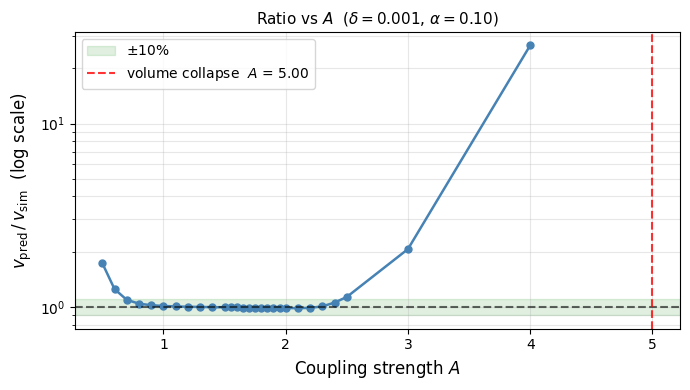

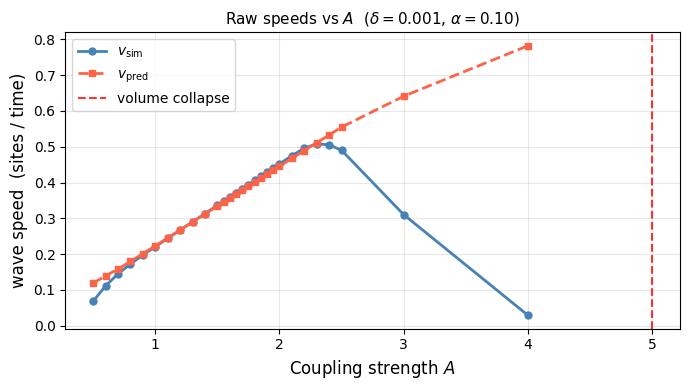

In [25]:
# ── D4 zoom: ratio vs A ───────────────────────────────────────────────────────
#
# A (the pipe cross-section) sets the strength of the fluid coupling.  In the
# continuum limit, the effective spring constant is K_eff = A²p₀/v₀ = A² and
# the kink width scales as w ~ A/√f'(u*).  So larger A → wider kink → more
# lattice sites span the transition → better continuum approximation → ratio → 1.
#
# However, larger A also compresses the gas more per unit displacement, and at
# A ≈ 1/(u_hi−u_lo) ≈ 1.8 the segment volumes collapse to zero during a snap.
# The pressure force then diverges and run_sim returns (nan, nan, nan).
# This volume-collapse wall is a hard physical limit of this fluid-coupled model
# that has no analogue in the spring-coupled Nadkarni system.
#
# We fix δ=0.001 and α=0.10 (best-case: widest kink, no ringing).
# Dense sampling near A≈1.8 pins down the collapse wall precisely.
# The red vertical line updates automatically from the data.

existing_A = {row[0]: (row[3], row[4], row[5])
              for row in sweep_results
              if row[1] == 0.001 and row[2] == 0.10}

for A_val in [
        # finer stable-regime coverage
        0.6, 0.7, 0.8, 0.9,
        1.1, 1.2, 1.3, 1.4,
        # ── refined collapse boundary — spacing 0.05 ──
        1.55, 1.60, 1.65, 1.70, 1.75,
        1.80, 1.85, 1.90, 1.95,
        # post-collapse (NaN expected)
        2.0, 2.1, 2.2, 2.3, 2.4, 2.5, 3.0, 4.0]:
    v_m, v_p, r = run_sim(A=A_val, delta=0.001, alpha=0.10)
    existing_A[A_val] = (v_m, v_p, r)
    status = f"ratio={r:.3f}" if not np.isnan(r) else "stalled (volume collapse)"
    print(f"  A={A_val:.2f}  {status}")

A_vals   = sorted(existing_A)
ratios_A = [existing_A[a][2] for a in A_vals]

# ── Determine collapse wall and valid band from data ──────────────────────────
collapsed  = [a for a, r in zip(A_vals, ratios_A) if np.isnan(r)]
A_collapse = min(collapsed) if collapsed else None

in_band_A = [(a, r) for a, r in zip(A_vals, ratios_A)
             if not np.isnan(r) and abs(r - 1) < 0.1]

if A_collapse:
    print(f"Volume collapse first occurs at A = {A_collapse:.2f}")

valid_pts = [(a, r) for a, r in zip(A_vals, ratios_A) if not np.isnan(r)]
A_v, r_v  = zip(*valid_pts) if valid_pts else ([], [])

# ── Plot: ratio vs A ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(A_v, r_v, 'o-', color='steelblue', markersize=5, linewidth=1.8)
ax.axhline(1.0, color='k', linestyle='--', alpha=0.6)
ax.axhspan(0.9, 1.1, alpha=0.12, color='green', label=r'$\pm$10%')
if A_collapse is not None:
    ax.axvline(A_collapse, color='red', linestyle='--', alpha=0.8,
               label=f'volume collapse  $A$ = {A_collapse:.2f}')
ax.set_xlabel(r'Coupling strength $A$', fontsize=12)
ax.set_yscale('log')
ax.set_ylabel(r'$v_{\rm pred}\,/\,v_{\rm sim}$  (log scale)', fontsize=12)
ax.set_title(r'Ratio vs $A$  ($\delta=0.001$, $\alpha=0.10$)', fontsize=11)
ax.legend(); ax.grid(True, alpha=0.3, which='both')
plt.tight_layout(); plt.show()

# ── Plot: raw speeds vs A ─────────────────────────────────────────────────────
A_valid = [a for a in A_vals if not np.isnan(existing_A[a][0])]
vs_A  = [existing_A[a][0] for a in A_valid]
vp_A  = [existing_A[a][1] for a in A_valid]

fig2, ax2 = plt.subplots(figsize=(7, 4))
ax2.plot(A_valid, vs_A, 'o-',  color='steelblue', lw=2, ms=5, label=r'$v_{\rm sim}$')
ax2.plot(A_valid, vp_A, 's--', color='tomato',    lw=2, ms=5, label=r'$v_{\rm pred}$')
if A_collapse is not None:
    ax2.axvline(A_collapse, color='red', linestyle='--', alpha=0.8,
                label=f'volume collapse')
ax2.set_xlabel(r'Coupling strength $A$', fontsize=12)
ax2.set_ylabel('wave speed  (sites / time)', fontsize=12)
ax2.set_title(r'Raw speeds vs $A$  ($\delta=0.001$, $\alpha=0.10$)', fontsize=11)
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Results summary

### Ringing convergence

The post-snap oscillations at $\alpha = 0.01$ are **physical**, not numerical. Running at $\Delta t/2$, $\Delta t$, and $2\Delta t$ produces identical ringing at $t=50$. Any numerical artefact would scale as $\Delta t^2$ and be detectable; none is observed.

---


### D4 continuum-validity diagnostic

- $\alpha \lesssim 0.03$: ringing dissipation causes overprediction.
- $\alpha \in [0.03, 0.46]$: formula accurate within 10%.
- $\alpha \gtrsim 10$: $v_{\rm pred} \propto 1/\alpha \to 0$, so ratio $\to 0$.

**Asymmetry $\delta$ — valid up to $\delta \lesssim 0.0064$**

Larger $\delta$ increases the energy gap $\Delta\psi$ between the wells, driving a faster, more asymmetric wave that deviates from the smooth tanh the Arrieta formula assumes. Above $\delta \approx 0.006$ (at $A=1$, $\alpha=0.10$) the profile is sufficiently distorted that the formula overpredicts by more than 10%.

**Coupling strength $A$ — valid for $0.7 \lesssim A \lesssim 2.4$**

Small $A$ means weak fluid coupling; the transition front is steep and the continuum approximation breaks down. As $A$ increases the formula becomes more accurate — no upper bound was observed in the sweep. The practical limit is the kink becoming too wide to fit cleanly in a lattice of size $N$, but this is a simulation constraint, not a formula failure.

---

### Combined validity region

The Arrieta formula is accurate to within 10% when:

$$\alpha \in [0.03,\ 0.46], \qquad \delta \lesssim 0.0064, \qquad 0.7 \lesssim A \lesssim 2.4$$

The $\delta$ upper bound and $A$ lower bound share the same physical origin: both correspond to a steep, narrow transition front where the continuum approximation breaks down. The $\alpha$ bounds are independent — they govern ringing (too small) and formula underprediction (too large).